In [8]:
import xarray as xr
import geopandas as gpd
import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

from cartopy.mpl.path import shapely_to_path
from matplotlib.path import Path
from matplotlib.patches import PathPatch

O arquivo não possui projeção
Definindo a projeção do dataset: 4674


Text(0.5, 1.0, 'Recorte Visual com Clip Path para MG')

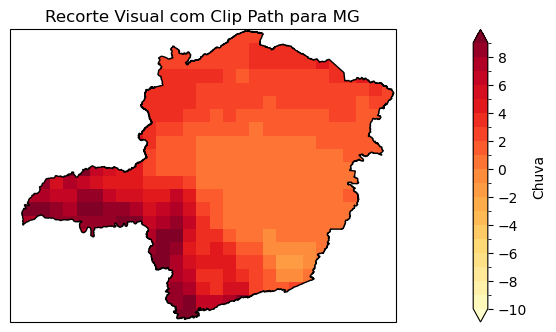

In [9]:
###########################################################################################################
def processa_shapefile(arquivo_shapefile):
    gdf = gpd.read_file(arquivo_shapefile)
    geometria = gdf.geometry
    projecao = gdf.crs
    epsg = projecao.to_authority()[1] # Retorna somente o EPSG (valor).
    return gdf, geometria, epsg
###########################################################################################################
def processa_netcdf(nome_arquivo_netcdf, epsg):
    # Não precisa se preocupar se a variável está de norte para sul ou vice-versa.
    ds = xr.open_dataset(nome_arquivo_netcdf)
    projecao = ds.rio.crs
    if projecao == None:
        print(f'O arquivo não possui projeção')
        # https://corteva.github.io/rioxarray/stable/getting_started/crs_management.html
        ds = ds.rio.write_crs(epsg) # Mesma projeção do shapefile.
        projecao = ds.rio.crs
        print(f'Definindo a projeção do dataset: {epsg}')
        # Remover o time_bnds do ds se existir.
        if 'time_bnds' in ds.variables:
            ds = ds.drop_vars('time_bnds')
        # Converte a longitude de 0-360 para -180 a +180, se necessário.
        if 'lon' in ds.coords and (ds.lon > 180).any():
            ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby('lon')
    return ds
###########################################################################################################
def aplica_mascara_rioxarray(dataset, geometria, projecao, all_touched=False):
    # False: São considerados todos os pontos que estão dentro da geometria do shapefile.
    # True: São considerados todos os pontos que estão dentro ou que intersectam a geometria do shapefile.
    # Renomeia as coordenadas para 'x' e 'y' se necessário.
    rename_dict = {}
    if 'lon' in dataset.dims:
        rename_dict['lon'] = 'x'
    elif 'longitude' in dataset.dims:
        rename_dict['longitude'] = 'x'
    if 'lat' in dataset.dims:
        rename_dict['lat'] = 'y'
    elif 'latitude' in dataset.dims:
        rename_dict['latitude'] = 'y'
    if rename_dict:
        dataset = dataset.rename(rename_dict)
    dado_mascarado = dataset.rio.clip(geometria, projecao, all_touched=all_touched)
    # Renomear x para lon e y para lat.
    dado_mascarado = dado_mascarado.rename({'x': 'lon', 'y': 'lat'})
    return dado_mascarado
###########################################################################################################
def suavizar_borda(gdf, plot, ax):
    """
    Suaviza visualmente a borda do recorte aplicado ao plot com base na geometria do shapefile.

    A função une as geometrias do `GeoDataFrame`, converte o resultado para um
    `Path` do Matplotlib, aplica esse caminho como máscara visual no objeto de plot
    e desenha o contorno da área no eixo cartográfico.

    Parâmetros
    ----------
    gdf : geopandas.GeoDataFrame
        GeoDataFrame contendo a geometria usada como limite espacial.
    plot : matplotlib.collections.QuadMesh ou similar
        Objeto retornado pelo método de plotagem, no qual será aplicado o recorte visual.
    ax : cartopy.mpl.geoaxes.GeoAxes
        Eixo cartográfico onde o contorno da geometria será desenhado.

    Retorno
    -------
    None
        A função modifica o plot e o eixo diretamente, sem retornar valor.
    """
    # Une todas as geometrias do shapefile em uma única geometria composta (MultiPolygon ou Polygon).
    geom_mg = gdf.geometry.union_all()
    
    # Converte a geometria do shapefile em um caminho (Path) do Matplotlib, que pode ser usado para recorte visual.
    paths = shapely_to_path(geom_mg)
    
    # Junta os caminhos em um único caminho composto, se necessário.
    clip_path = Path.make_compound_path(*paths) if isinstance(paths, (list, tuple)) else paths
    
    # Limita a exibição dos dados ao interior do shapefile.
    clip_patch = PathPatch(clip_path, transform=ax.transData, facecolor="none")
    
    # Aplica o recorte visual no dataset. Apenas informações dentro do limite do shapefile serão exibidas.
    plot.set_clip_path(clip_patch)

    # Desenha o contorno do shapefile.
    ax.add_geometries([geom_mg],crs=ccrs.PlateCarree(),edgecolor='black',facecolor='none',linewidth=1)
###########################################################################################################    

# Tratamento dos dados.
arquivo_netcdf = 'chuva_diaria_20260129.nc' # Arquivo NetCDF do modelo europeu na resolução de 40km.
arquivo_shapefile = '/mnt/c/Users/guilherme.martins/guilherme/base_dados/shapefile/IBGE/MG/MG_UF_2022.shp'

gdf, geometria, epsg = processa_shapefile(arquivo_shapefile=arquivo_shapefile)
ds = processa_netcdf(arquivo_netcdf, epsg)
dado_mascarado = aplica_mascara_rioxarray(ds, geometria, epsg, True)

fig, ax = plt.subplots(figsize=(20,3.8), subplot_kw={'projection': ccrs.PlateCarree()})

plot = dado_mascarado['prec'].plot(
    cmap='YlOrRd',
    levels=np.arange(-10, 10, 1),
    ax=ax,
    transform=ccrs.PlateCarree(),
    add_colorbar=True,
    cbar_kwargs={"label": "Chuva"},
    extend='both'
)

plot = suavizar_borda(gdf, plot, ax)

ax.set_title('Recorte Visual com Clip Path para MG')